# Example 3: Clustering Regulons into Programs and Patients into States

This notebook demonstrates the program and state discovery step of the gbmMINER pipeline.

## Background

After network quantization, each regulon has a discrete activity value (-1, 0, +1)
per patient. The next step is to find structure in this matrix:

**Programs** — groups of regulons with similar activity patterns across patients.
Regulons in the same program tend to be overactive in the same patients and
underactive in the same patients, suggesting they are part of the same
biological process.

**States** — groups of patients with similar program activity profiles.
Patients in the same state have similar combinations of active and inactive
programs, potentially reflecting different disease subtypes.

The key insight is that we cluster **regulons** first (into programs), then
summarise program activity per patient, then cluster **patients** (into states).
This two-step reduction makes the data more interpretable and less noisy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from joblib import Parallel, delayed

## 1. Simulate a quantized matrix

We create a synthetic quantized matrix with 3 clear regulon clusters
to demonstrate that program discovery works as expected.

In [2]:
np.random.seed(42)
n_regulons = 60
n_patients = 100

regulon_ids = list(range(n_regulons))
patient_ids = [f'PATIENT_{i}' for i in range(n_patients)]

# Create base matrix of zeros
Q = np.zeros((n_regulons, n_patients), dtype=np.int8)

# Inject 3 clear regulon clusters, each active in different patient subgroups
# Cluster A: regulons 0-19, overactive in patients 0-33
Q[0:20,  0:33]  = 1
Q[0:20,  33:66] = -1

# Cluster B: regulons 20-39, overactive in patients 33-66
Q[20:40, 33:66] = 1
Q[20:40, 66:]   = -1

# Cluster C: regulons 40-59, overactive in patients 66-99
Q[40:60, 66:]   = 1
Q[40:60, 0:33]  = -1

# Add noise
noise_mask = np.random.rand(n_regulons, n_patients) < 0.1
Q[noise_mask] = np.random.choice([-1, 0, 1], size=noise_mask.sum())

quantized_matrix = pd.DataFrame(Q, index=regulon_ids, columns=patient_ids)

print(f"Quantized matrix shape: {quantized_matrix.shape}")
print(f"Value counts:")
print(pd.Series(Q.flatten()).value_counts())

Quantized matrix shape: (60, 100)
Value counts:
-1    2007
 1    2003
 0    1990
Name: count, dtype: int64


## 2. Variance filtering

Not all regulons vary meaningfully across patients — some are nearly always 0.
These add noise to clustering without adding signal.

We keep only the top 50% most variable regulons (by std across patients).
A regulon with std ≈ 0 is almost always neutral — uninformative for clustering.

Std distribution across regulons:
count    60.000000
mean      0.820530
std       0.012682
min       0.791112
25%       0.810225
50%       0.821123
75%       0.828532
max       0.850668
dtype: float64


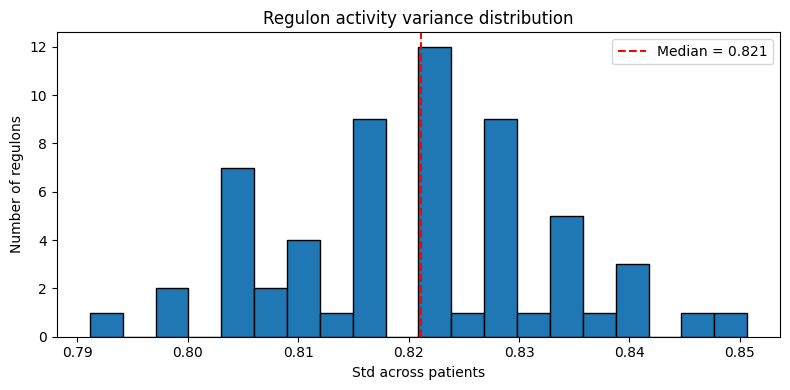

In [3]:
row_std = quantized_matrix.std(axis=1)

print(f"Std distribution across regulons:")
print(row_std.describe())

# Plot distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(row_std, bins=20, edgecolor='black')
ax.axvline(row_std.median(), color='red', linestyle='--',
           label=f'Median = {row_std.median():.3f}')
ax.set_xlabel('Std across patients')
ax.set_ylabel('Number of regulons')
ax.set_title('Regulon activity variance distribution')
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# Filter to top 50% most variable
threshold      = row_std.median()
active_regulons = row_std[row_std > threshold].index
print(f"Active regulons (top 50%): {len(active_regulons)} of {n_regulons}")

X_active = quantized_matrix.loc[active_regulons].values.astype(float)
print(f"X_active shape: {X_active.shape}  (active regulons x patients)")

Active regulons (top 50%): 29 of 60
X_active shape: (29, 100)  (active regulons x patients)


## 3. Find optimal number of programs — gap statistic

The gap statistic compares the inertia of your actual clustering to the inertia
of clustering random data with the same shape. A large gap means your clusters
are more structured than random — indicating a good k.

This is more robust than silhouette score alone for data with weak cluster structure.

Computing gap statistic...


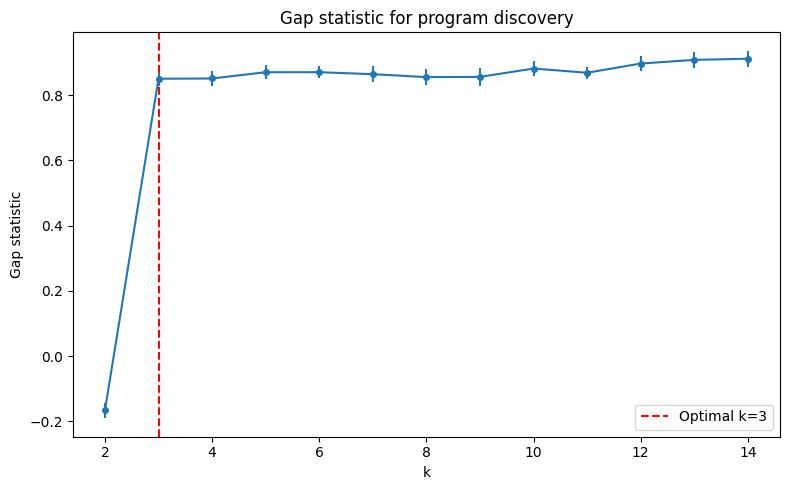


Optimal k for programs: 3


In [6]:
def compute_gap(k, X, n_refs=10, random_state=42):
    km = KMeans(n_clusters=k, random_state=random_state, n_init=5)
    actual_inertia = np.log(km.fit(X).inertia_)
    
    rng = np.random.RandomState(random_state)
    X_min, X_max = X.min(), X.max()
    ref_inertias = [
        np.log(KMeans(n_clusters=k, random_state=i, n_init=3)
               .fit(rng.uniform(X_min, X_max, size=X.shape)).inertia_)
        for i in range(n_refs)
    ]
    return np.mean(ref_inertias) - actual_inertia, np.std(ref_inertias)

k_range = range(2, 15)
print("Computing gap statistic...")

results  = Parallel(n_jobs=-1)(delayed(compute_gap)(k, X_active) for k in k_range)
gaps     = np.array([r[0] for r in results])
gaps_std = np.array([r[1] for r in results])

# Optimal k: smallest k where gap[k] >= gap[k+1] - std[k+1]
optimal_k = list(k_range)[0]
for i in range(len(gaps) - 1):
    if gaps[i] >= gaps[i+1] - gaps_std[i+1]:
        optimal_k = list(k_range)[i]
        break

plt.figure(figsize=(8, 5))
plt.errorbar(k_range, gaps, yerr=gaps_std, marker='o', markersize=4)
plt.axvline(x=optimal_k, color='red', linestyle='--',
            label=f'Optimal k={optimal_k}')
plt.xlabel('k'); plt.ylabel('Gap statistic')
plt.title('Gap statistic for program discovery')
plt.legend(); plt.tight_layout(); plt.show()

print(f"\nOptimal k for programs: {optimal_k}")
# Should recover k=3 since we injected 3 clear clusters

## 4. Fit final program model

KMeans assigns each active regulon to one of k programs.
A healthy program distribution has no single program dominating —
roughly equal numbers of regulons per program.

Regulons per program:
0    12
1    10
2     7
Name: count, dtype: int64


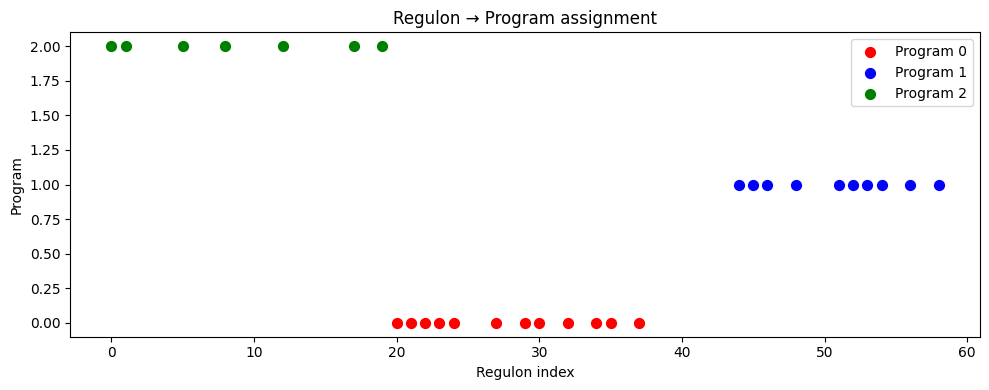

In [7]:
km_programs = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
program_labels = km_programs.fit_predict(X_active)

# program_series: maps each regulon index → its program (0 to k-1)
program_series = pd.Series(program_labels, index=active_regulons)

print("Regulons per program:")
print(program_series.value_counts().sort_index())

# Visualise which regulons ended up in which program
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['red', 'blue', 'green', 'orange', 'purple']
for prog in range(optimal_k):
    regs = program_series[program_series == prog].index
    ax.scatter(regs, [prog]*len(regs),
               color=colors[prog % len(colors)],
               label=f'Program {prog}', s=50)
ax.set_xlabel('Regulon index')
ax.set_ylabel('Program')
ax.set_title('Regulon → Program assignment')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

## 5. Compute program activity per patient

For each program, we summarise its activity in each patient as the
**mean quantized value** across all regulons in that program.

This gives a single score per program per patient — collapsing the
(n_regulons × n_patients) matrix into an (n_programs × n_patients) matrix.

In [8]:
program_activity = pd.DataFrame(
    index=range(optimal_k),
    columns=quantized_matrix.columns
)

for prog in range(optimal_k):
    regs_in_prog = program_series[program_series == prog].index.tolist()
    program_activity.loc[prog] = quantized_matrix.loc[regs_in_prog].mean(axis=0)

program_activity = program_activity.astype(float)
print(f"Program activity matrix: {program_activity.shape}")
print(f"  Rows    = programs ({optimal_k})")
print(f"  Columns = patients ({n_patients})")
print(f"\nPreview (first 5 patients):")
print(program_activity.iloc[:, :5].round(3))

Program activity matrix: (3, 100)
  Rows    = programs (3)
  Columns = patients (100)

Preview (first 5 patients):
   PATIENT_0  PATIENT_1  PATIENT_2  PATIENT_3  PATIENT_4
0     -0.083      0.000      0.083     -0.083        0.0
1     -1.000     -0.700     -1.000     -0.900       -0.9
2      0.857      0.571      0.857      1.000        1.0


## 6. Find optimal number of patient states

Now we cluster **patients** based on their program activity profiles.
Each patient is described by k numbers — one activity score per program.

We use the same gap statistic approach.

X_patients shape: (100, 3)  (patients x programs)
Computing gap statistic for states...


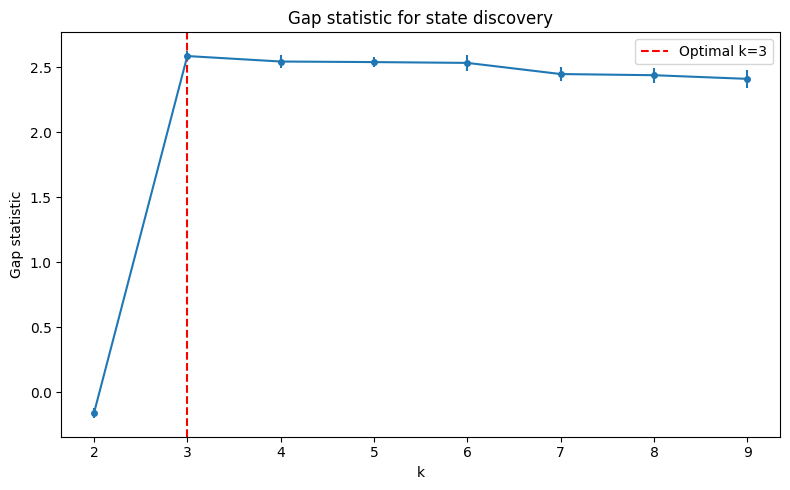


Optimal k for states: 3


In [9]:
# X_patients: 100 patients x k programs
X_patients = program_activity.T.values
print(f"X_patients shape: {X_patients.shape}  (patients x programs)")

k_range_states = range(2, 10)
print("Computing gap statistic for states...")

results_s  = Parallel(n_jobs=-1)(delayed(compute_gap)(k, X_patients) for k in k_range_states)
gaps_s     = np.array([r[0] for r in results_s])
gaps_std_s = np.array([r[1] for r in results_s])

optimal_k_states = list(k_range_states)[0]
for i in range(len(gaps_s) - 1):
    if gaps_s[i] >= gaps_s[i+1] - gaps_std_s[i+1]:
        optimal_k_states = list(k_range_states)[i]
        break

plt.figure(figsize=(8, 5))
plt.errorbar(k_range_states, gaps_s, yerr=gaps_std_s, marker='o', markersize=4)
plt.axvline(x=optimal_k_states, color='red', linestyle='--',
            label=f'Optimal k={optimal_k_states}')
plt.xlabel('k'); plt.ylabel('Gap statistic')
plt.title('Gap statistic for state discovery')
plt.legend(); plt.tight_layout(); plt.show()

print(f"\nOptimal k for states: {optimal_k_states}")

## 7. Fit final state model

In [10]:
km_states = KMeans(n_clusters=optimal_k_states, random_state=42, n_init=10)
state_labels = km_states.fit_predict(X_patients)
state_series = pd.Series(state_labels, index=program_activity.columns)

print("Patients per state:")
print(state_series.value_counts().sort_index())

# Summary of full pipeline
print(f"\n--- Pipeline summary ---")
print(f"Input:            {n_regulons} regulons x {n_patients} patients")
print(f"After filtering:  {len(active_regulons)} active regulons")
print(f"Programs:         {optimal_k}")
print(f"Patient states:   {optimal_k_states}")

Patients per state:
0    33
1    34
2    33
Name: count, dtype: int64

--- Pipeline summary ---
Input:            60 regulons x 100 patients
After filtering:  29 active regulons
Programs:         3
Patient states:   3
